# Netflix Content Clustering

This notebook clusters the Netflix catalog using **K-Means** on genre, rating, release year, and duration features.  
It produces:
- An **elbow plot** to choose the optimal `k`
- A **silhouette score** to evaluate cluster quality
- A **PCA scatter plot** for 2-D visual inspection
- A saved `kmeans_model.pkl` for use in the API or downstream tasks

---

**Dataset:** `data/netflix_titles.csv`  
**Output model:** `models/kmeans_model.pkl`

## 1. Imports & Configuration

In [1]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler

warnings.filterwarnings('ignore')

# ── Paths (relative to notebook location inside notebooks/) ───────────────
BASE_DIR   = Path('.').resolve().parent
DATA_PATH  = BASE_DIR / 'data'   / 'netflix_titles.csv'
MODEL_DIR  = BASE_DIR / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
N_CLUSTERS   = 5   # can be changed after inspecting the elbow plot

print(f'Dataset : {DATA_PATH}')
print(f'Model dir: {MODEL_DIR}')

Dataset : C:\Users\hp\OneDrive\Documents\Data Science Projects\netflix_atlas_production\netflix_atlas\data\netflix_titles.csv
Model dir: C:\Users\hp\OneDrive\Documents\Data Science Projects\netflix_atlas_production\netflix_atlas\models


## 2. Load & Clean Data

In [2]:
df = pd.read_csv(DATA_PATH)

# ── Basic cleaning ─────────────────────────────────────────────────────────
before = len(df)
df.drop_duplicates(subset='show_id', inplace=True)
print(f'Removed {before - len(df)} duplicate rows. Remaining: {len(df)}')

df.fillna('Unknown', inplace=True)

# ── Genre list ─────────────────────────────────────────────────────────────
df['genre_list'] = df['listed_in'].apply(lambda x: [g.strip() for g in x.split(',')])

# ── Numeric duration ───────────────────────────────────────────────────────
df['duration_num'] = (
    df['duration']
    .str.extract(r'(\d+)', expand=False)
    .pipe(pd.to_numeric, errors='coerce')
    .fillna(0)
    .astype(int)
)

print(df[['title', 'type', 'listed_in', 'duration_num', 'release_year', 'rating']].head())

Removed 0 duplicate rows. Remaining: 8807
                   title     type  \
0   Dick Johnson Is Dead    Movie   
1          Blood & Water  TV Show   
2              Ganglands  TV Show   
3  Jailbirds New Orleans  TV Show   
4           Kota Factory  TV Show   

                                           listed_in  duration_num  \
0                                      Documentaries            90   
1    International TV Shows, TV Dramas, TV Mysteries             2   
2  Crime TV Shows, International TV Shows, TV Act...             1   
3                             Docuseries, Reality TV             1   
4  International TV Shows, Romantic TV Shows, TV ...             2   

   release_year rating  
0          2020  PG-13  
1          2021  TV-MA  
2          2021  TV-MA  
3          2021  TV-MA  
4          2021  TV-MA  


## 3. Feature Engineering

In [3]:
# ── Genre one-hot encoding via MultiLabelBinarizer ─────────────────────────
mlb = MultiLabelBinarizer()
genre_encoded = mlb.fit_transform(df['genre_list'])
print(f'Genre categories ({len(mlb.classes_)}): {mlb.classes_[:10]} …')

# ── Ordinal rating encoding ────────────────────────────────────────────────
RATING_ORDER = {
    'G': 1, 'TV-Y': 1, 'TV-G': 1,
    'PG': 2, 'TV-Y7': 2, 'TV-PG': 2,
    'PG-13': 3, 'TV-14': 3,
    'R': 4, 'TV-MA': 4,
    'NC-17': 5,
}
df['rating_enc'] = df['rating'].map(RATING_ORDER).fillna(0).astype(int)

# ── Numeric feature matrix ─────────────────────────────────────────────────
numeric_features = df[['release_year', 'duration_num', 'rating_enc']].fillna(0).values

# ── Concatenate all features ───────────────────────────────────────────────
X = np.concatenate([numeric_features, genre_encoded], axis=1)
print(f'Feature matrix shape: {X.shape}')

Genre categories (42): ['Action & Adventure' 'Anime Features' 'Anime Series' 'British TV Shows'
 'Children & Family Movies' 'Classic & Cult TV' 'Classic Movies'
 'Comedies' 'Crime TV Shows' 'Cult Movies'] …
Feature matrix shape: (8807, 45)


## 4. Scaling

In [4]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Scaling complete. Mean ~0:', X_scaled.mean(axis=0)[:3].round(4))

Scaling complete. Mean ~0: [-0. -0. -0.]


## 5. Elbow Method — Choose Optimal k

  k= 2  WCSS=385,557  Silhouette=0.2386
  k= 3  WCSS=376,158  Silhouette=0.2426
  k= 4  WCSS=348,740  Silhouette=0.1846
  k= 5  WCSS=339,781  Silhouette=0.1873
  k= 6  WCSS=329,382  Silhouette=0.2185
  k= 7  WCSS=322,733  Silhouette=0.2205
  k= 8  WCSS=305,106  Silhouette=0.1081
  k= 9  WCSS=295,663  Silhouette=0.1291
  k=10  WCSS=286,657  Silhouette=0.1479
  k=11  WCSS=277,682  Silhouette=0.1573


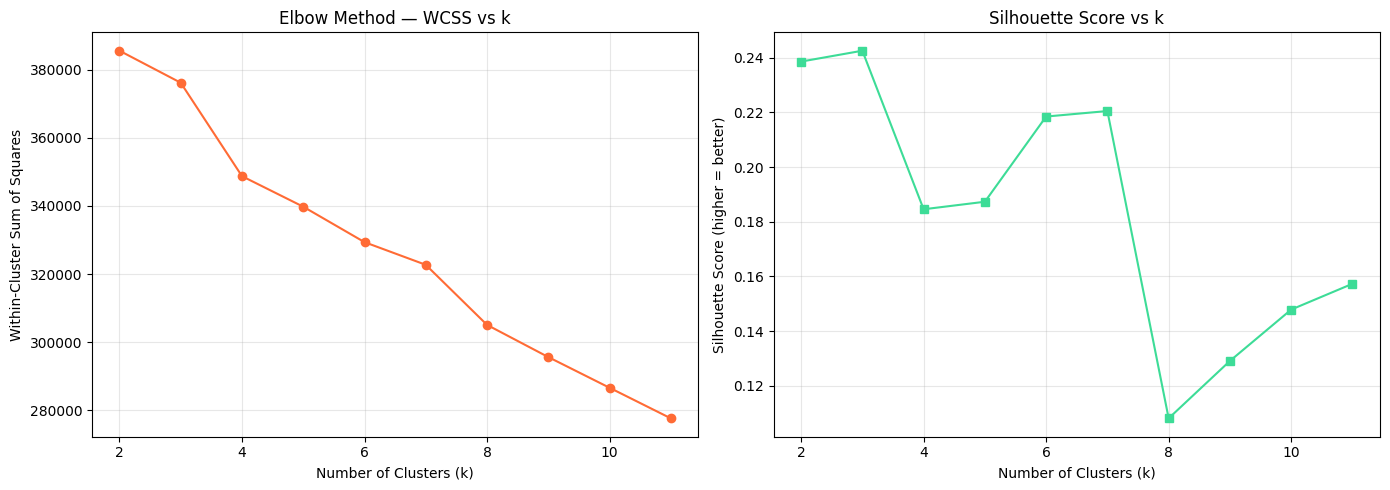

Plot saved to models/elbow_plot.png


In [5]:
k_range = range(2, 12)
wcss    = []
sil     = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init='auto')
    labels = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    sil.append(silhouette_score(X_scaled, labels, sample_size=2000, random_state=RANDOM_STATE))
    print(f'  k={k:2d}  WCSS={km.inertia_:,.0f}  Silhouette={sil[-1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, wcss, marker='o', color='#ff6b35')
axes[0].set_title('Elbow Method — WCSS vs k')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Within-Cluster Sum of Squares')
axes[0].grid(alpha=0.3)

axes[1].plot(k_range, sil, marker='s', color='#3ddc97')
axes[1].set_title('Silhouette Score vs k')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score (higher = better)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(MODEL_DIR / 'elbow_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to models/elbow_plot.png')

## 6. Train Final K-Means Model

In [6]:
# Set N_CLUSTERS based on the elbow / silhouette plots above
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init='auto')
labels = kmeans.fit_predict(X_scaled)
df['cluster'] = labels

final_sil = silhouette_score(X_scaled, labels, sample_size=3000, random_state=RANDOM_STATE)
print(f'Final model  k={N_CLUSTERS}  Silhouette Score = {final_sil:.4f}')
print(f'Cluster distribution:\n{df["cluster"].value_counts().sort_index()}')

Final model  k=5  Silhouette Score = 0.1931
Cluster distribution:
cluster
0     173
1    6131
2      69
3    2418
4      16
Name: count, dtype: int64


## 7. PCA Visualisation

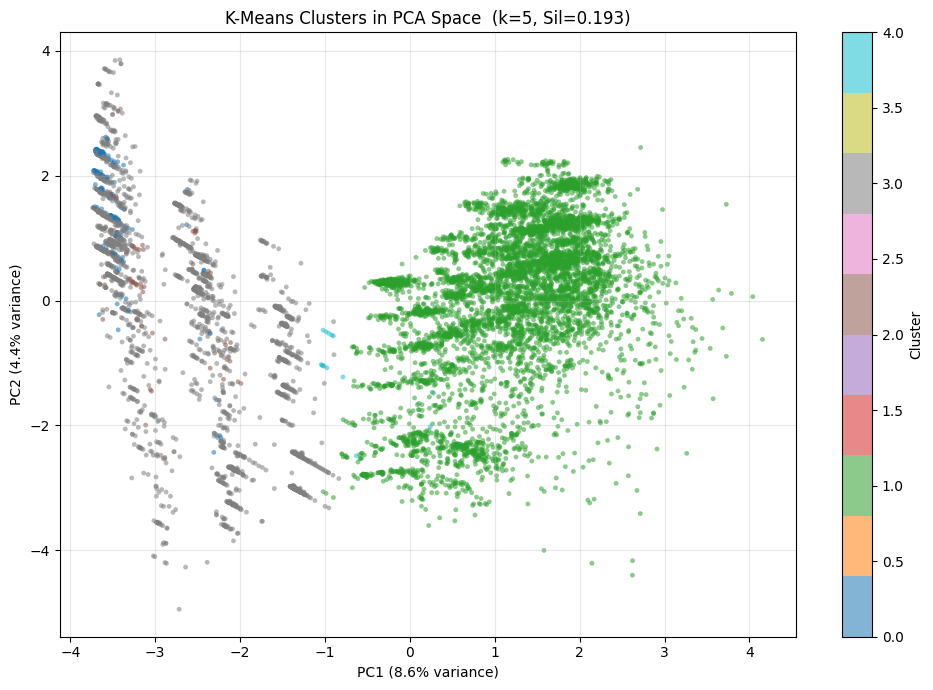

Plot saved to models/pca_clusters.png


In [7]:
pca    = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca  = pca.fit_transform(X_scaled)
var_ex = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=labels, cmap='tab10', alpha=0.55, s=12, linewidths=0
)
plt.colorbar(scatter, ax=ax, label='Cluster')
ax.set_title(f'K-Means Clusters in PCA Space  (k={N_CLUSTERS}, Sil={final_sil:.3f})')
ax.set_xlabel(f'PC1 ({var_ex[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({var_ex[1]*100:.1f}% variance)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(MODEL_DIR / 'pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to models/pca_clusters.png')

## 8. Cluster Profiles

In [8]:
profile = (
    df.groupby('cluster')
    .agg(
        count        = ('show_id',      'count'),
        avg_year     = ('release_year', 'mean'),
        avg_duration = ('duration_num', 'mean'),
        top_type     = ('type',         lambda s: s.value_counts().index[0]),
        top_rating   = ('rating',       lambda s: s.value_counts().index[0]),
    )
    .round(1)
)
print(profile.to_string())

         count  avg_year  avg_duration top_type top_rating
cluster                                                   
0          173    2017.5           1.5  TV Show      TV-MA
1         6131    2013.1          99.5    Movie      TV-MA
2           69    2016.3           2.2  TV Show      TV-14
3         2418    2016.7           1.8  TV Show      TV-MA
4           16    1999.4           1.0  TV Show      TV-14


## 9. Save Model & Artefacts

In [9]:
model_path  = MODEL_DIR / 'kmeans_model.pkl'
scaler_path = MODEL_DIR / 'scaler.pkl'
mlb_path    = MODEL_DIR / 'mlb.pkl'
cluster_csv = MODEL_DIR / 'netflix_clustered.csv'

joblib.dump(kmeans, model_path)
joblib.dump(scaler, scaler_path)
joblib.dump(mlb,    mlb_path)
df.to_csv(cluster_csv, index=False)

print(f'Saved:\n  {model_path}\n  {scaler_path}\n  {mlb_path}\n  {cluster_csv}')

Saved:
  C:\Users\hp\OneDrive\Documents\Data Science Projects\netflix_atlas_production\netflix_atlas\models\kmeans_model.pkl
  C:\Users\hp\OneDrive\Documents\Data Science Projects\netflix_atlas_production\netflix_atlas\models\scaler.pkl
  C:\Users\hp\OneDrive\Documents\Data Science Projects\netflix_atlas_production\netflix_atlas\models\mlb.pkl
  C:\Users\hp\OneDrive\Documents\Data Science Projects\netflix_atlas_production\netflix_atlas\models\netflix_clustered.csv
